# PRML Mini Project 1 - Task C

Single-notebook starter for Human Activity Recognition.

In [26]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import resample
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

try:
    from umap import UMAP
except ImportError:
    UMAP = None

np.random.seed(42)
random.seed(42)
sns.set_theme(style='whitegrid')

RANDOM_STATE= 42
EXPECTED_AXES= ('x', 'y', 'z')
ACTIVITY_MAP= {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING',
}
COMMON_AXIS_ALIASES={
    'x': ['x', 'acc_x', 'accel_x', 'acceleration_x', 'linear_acceleration_x'],
    'y': ['y', 'acc_y', 'accel_y', 'acceleration_y', 'linear_acceleration_y'],
    'z': ['z', 'acc_z', 'accel_z', 'acceleration_z', 'linear_acceleration_z'],
}

@dataclass
class SplitBundle:
    X_train: pd.DataFrame
    X_val: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_val: pd.Series
    y_test: pd.Series

def zero_crossing_rate(values):
    #αφαίρεση μέσης τιμής
    centered = values-np.mean(values)
    #πρόσημο κάθε τιμής
    signs= np.sign(centered)
    signs[signs== 0]= 1  #αν πρόσημο 0, γίνε 1
    # Ποσοστό αλλαγών προσήμου
    return float(np.mean(signs[:-1]!= signs[1:])) if len(signs)> 1 else 0.0

def dominant_frequency(values, sample_rate_hz=50.0):
    if len(values) < 2:
        return 0.0
    centered= values-np.mean(values)
    #Fourier
    spectrum= np.abs(np.fft.rfft(centered))
    freqs= np.fft.rfftfreq(len(centered), d=1.0 / sample_rate_hz)
    if len(spectrum) <= 1:
        return 0.0
    spectrum[0] = 0.0  #αγνόησε σταθερή συνιστώσα
    return float(freqs[int(np.argmax(spectrum))])

def feature_names():
    #ονόματα όλων των features
    names= []
    #βασικά στατιστικά (mean, std, min, max) ανά άξονα
    for axis in EXPECTED_AXES:
        for stat in ('mean', 'std', 'min', 'max'):
            names.append(f'{axis}_{stat}')
    #Μέγεθος διανύσματος επιτάχυνσης
    names.extend(['magnitude_mean', 'magnitude_std'])
    #διασταυρώσεις μηδέν
    names.extend([f'{axis}_zcr' for axis in EXPECTED_AXES])
    #Jerk, αλλαγή της επιτάχυνσης
    names.extend([f'{axis}_jerk_mean' for axis in EXPECTED_AXES])
    names.extend([f'{axis}_jerk_std' for axis in EXPECTED_AXES])
    #δυσκολότερη συχνότητα
    names.extend([f'{axis}_dominant_freq' for axis in EXPECTED_AXES])
    return names

def extract_har_features(window_xyz, sample_rate_hz=50.0):
    x,y,z = window_xyz.T
    features=[]
    #βασικά στατιστικά για κάθε άξονα
    for axis in (x, y, z):
        features.extend([float(np.mean(axis)), float(np.std(axis)), float(np.min(axis)), float(np.max(axis))])
    #μέγεθος και στατιστικά του
    mag= np.sqrt(x**2 + y**2 + z**2)
    features.extend([float(np.mean(mag)), float(np.std(mag))])
    #Zero crossing rate για κάθε άξονα
    for axis in (x, y, z):
        features.append(zero_crossing_rate(axis))
    #Jerk/πρώτη παράγωγος για κάθε άξονα
    for axis in (x, y, z):
        jerk= np.diff(axis)
        features.extend([float(np.mean(jerk)) if len(jerk) else 0.0, float(np.std(jerk)) if len(jerk) else 0.0])
    #δυσκολότερη συχνότητα για κάθε άξονα
    for axis in (x, y, z):
        features.append(dominant_frequency(axis, sample_rate_hz=sample_rate_hz))
    return pd.Series(features, index=feature_names())

def load_ucihar_raw(dataset_root):
    dataset_root= Path(dataset_root)
    parts= []
    labels= []
    #train και test χωριστά
    for split in ('train', 'test'):
        signal_dir= dataset_root / split / 'Inertial Signals'
        # φόρτωση τα σήματα x, y, z
        total_acc= []
        for axis in EXPECTED_AXES:
            total_acc.append(np.loadtxt(signal_dir / f'total_acc_{axis}_{split}.txt'))
        # σε 3 διαστάσεις
        stacked= np.stack(total_acc, axis=-1)
        # features από κάθε δείγμα
        split_df= pd.DataFrame([extract_har_features(sample).to_dict() for sample in stacked])
        y= np.loadtxt(dataset_root / split / f'y_{split}.txt').astype(int)
        parts.append(split_df)
        labels.append(pd.Series(y))
    # train+test
    X= pd.concat(parts, ignore_index=True)
    # αριθμοί σε ονόματα δραστηριοτήτων
    y= pd.concat(labels, ignore_index=True).map(ACTIVITY_MAP)
    return X, y

def class_counts(y):
    # πλήθος δειγμάτων ανά κλάση
    counts = y.value_counts().sort_index()
    return counts.rename_axis('class').reset_index(name='count')

def stratified_train_val_test_split(X, y, random_state=RANDOM_STATE):
    #πρώτη διαίρεση: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=random_state)
    #δεύτερη διαίρεση: 50% val, 50% test από το temp
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state)
    return SplitBundle(X_train, X_val, X_test, y_train, y_val, y_test)

def split_class_counts(bundle):
    # πλήθος δειγμάτων ανά κλάση σε κάθε σύνολο
    tables= []
    for name, labels in (('train', bundle.y_train), ('val', bundle.y_val), ('test', bundle.y_test)):
        tables.append(labels.value_counts().sort_index().rename(name))
    return pd.concat(tables, axis=1).fillna(0).astype(int)

def preprocess_splits(bundle):
    # imputer και scaler
    imputer= SimpleImputer(strategy='median')
    scaler= StandardScaler()
    # Συμπλήρωση τιμών με διάμεσο
    X_train_imp= pd.DataFrame(imputer.fit_transform(bundle.X_train), columns=bundle.X_train.columns, index=bundle.X_train.index)
    X_val_imp= pd.DataFrame(imputer.transform(bundle.X_val), columns=bundle.X_val.columns, index=bundle.X_val.index)
    X_test_imp= pd.DataFrame(imputer.transform(bundle.X_test), columns=bundle.X_test.columns, index=bundle.X_test.index)
    # κανονικοποίηση δεδομένων
    X_train_scaled= pd.DataFrame(scaler.fit_transform(X_train_imp), columns=bundle.X_train.columns, index=bundle.X_train.index)
    X_val_scaled= pd.DataFrame(scaler.transform(X_val_imp), columns=bundle.X_val.columns, index=bundle.X_val.index)
    X_test_scaled= pd.DataFrame(scaler.transform(X_test_imp), columns=bundle.X_test.columns, index=bundle.X_test.index)
    processed = SplitBundle(X_train_scaled, X_val_scaled, X_test_scaled, bundle.y_train.copy(), bundle.y_val.copy(), bundle.y_test.copy())
    return processed, imputer, scaler

def missing_value_report(*frames):
    totals= sum(frame.isna().sum() for frame in frames)
    return totals[totals > 0].sort_values(ascending=False)

def plot_feature_histograms(X, y, features=None, max_features=6):
    # επιλογή features για σχεδίαση
    features= (features or list(X.columns[:max_features]))[:max_features]
    fig, axes= plt.subplots(len(features), 1, figsize=(10, 3 * len(features)), constrained_layout=True)
    if len(features) == 1:
        axes=[axes]
    # σχεδίαση ιστογράμματος ανά feature
    for ax, feature in zip(axes, features):
        for label in sorted(y.unique()):
            sns.histplot(X.loc[y == label, feature], ax=ax, stat='density', element='step', fill=False, label=label, bins=20)
        ax.set_title(f'Distribution of {feature}')
        ax.legend()
    plt.show()

def plot_correlation_heatmap(X, figsize=(16, 12)):
    #Υπολογισμός συσχέτισης μεταξύ features
    corr= X.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Heatmap')
    plt.show()
    return corr

def top_correlated_pairs(corr, threshold=0.85):
    # ζευγη με υψηλή συσχέτιση
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = corr.where(mask).stack().reset_index().rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'correlation'})
    pairs['abs_correlation'] = pairs['correlation'].abs()
    return pairs[pairs['abs_correlation'] >= threshold].sort_values('abs_correlation', ascending=False)

def plot_embeddings(X, y):
    # δημιουργία μειωμένων αναπαραστάσεων
    outputs={}
    reducers= {
        'PCA': PCA(n_components=2, random_state=RANDOM_STATE),
        't-SNE': TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto'),
    }
    if UMAP is not None:
        reducers['UMAP'] = UMAP(n_components=2, random_state=RANDOM_STATE)
    fig, axes = plt.subplots(1, len(reducers), figsize=(6 * len(reducers), 5), constrained_layout=True)
    if len(reducers) == 1:
        axes = [axes]
    # εφαρμογή κάθε μεθόδου μείωσης διαστάσεων
    for ax, (name, reducer) in zip(axes, reducers.items()):
        emb = reducer.fit_transform(X)
        outputs[name] = reducer
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=y, ax=ax, s=40)
        ax.set_title(name)
        ax.legend(loc='best', fontsize=8)
        if name == 'PCA':
            outputs['PCA_explained_variance_ratio'] = reducer.explained_variance_ratio_
    plt.show()
    return outputs

def model_search_spaces():
    return {
        'k-NN': (KNeighborsClassifier(), {'n_neighbors': [1, 3, 5, 11, 21], 'metric': ['euclidean', 'cosine']}),
        'Naive Bayes': (GaussianNB(), {}),
        'Logistic Regression': (LogisticRegression(max_iter=5000, random_state=RANDOM_STATE), {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}),
        'SVM': (SVC(random_state=RANDOM_STATE), {'kernel': ['linear', 'rbf', 'poly'], 'C': [0.1, 1, 10, 100]}),
        'Decision Tree': (DecisionTreeClassifier(random_state=RANDOM_STATE), {'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 5, 10]}),
    }

def run_model_selection(X_train, y_train, X_val, y_val, X_test, y_test):
    # CV splitter
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    results= []
    fitted_models= {}
    # πάντα την πιο συχνή κλάση
    baseline = DummyClassifier(strategy='most_frequent')
    baseline.fit(X_train, y_train)
    fitted_models['Naive Baseline'] = baseline
    baseline_val = baseline.predict(X_val)
    baseline_test = baseline.predict(X_test)
    results.append({'Algorithm': 'Naive Baseline', 'Best Params': {}, 'Val Acc (%)': 100 * accuracy_score(y_val, baseline_val), 'Test Acc (%)': 100 * accuracy_score(y_test, baseline_test), 'F1 macro (%)': 100 * f1_score(y_test, baseline_test, average='macro', zero_division=0)})
    #δοκιμή κάθε αλγορίθμου
    for name, (model, grid) in model_search_spaces().items():
        if grid:
            # για καλύτερες υπερπαραμέτρους
            search= GridSearchCV(model, grid, scoring='f1_macro', cv=cv, n_jobs=-1, refit=True)
            search.fit(X_train, y_train)
            best_model= search.best_estimator_
            best_params= search.best_params_
        else:
            # Χωρίς grid search, Naive Bayes
            best_model= clone(model).fit(X_train, y_train)
            best_params= {}
        fitted_models[name]= best_model
        # πρόβλεψη και αξιολόγηση
        val_pred= best_model.predict(X_val)
        test_pred= best_model.predict(X_test)
        results.append({'Algorithm': name, 'Best Params': best_params, 'Val Acc (%)': 100 * accuracy_score(y_val, val_pred), 'Test Acc (%)': 100 * accuracy_score(y_test, test_pred), 'F1 macro (%)': 100 * f1_score(y_test, test_pred, average='macro', zero_division=0)})
    # Ταξινόμηση
    results_df= pd.DataFrame(results).sort_values(['Val Acc (%)', 'F1 macro (%)'], ascending=False)
    return results_df, fitted_models

def evaluate_model(model, X, y):
    # Πρόβλεψη και υπολογισμός
    preds = model.predict(X)
    labels = sorted(y.unique())
    precision, recall, f1, support = precision_recall_fscore_support(y, preds, average=None, labels=labels, zero_division=0)
    per_class = pd.DataFrame({'class': labels, 'precision': precision, 'recall': recall, 'f1': f1, 'support': support})
    return {'accuracy': accuracy_score(y, preds), 'f1_macro': f1_score(y, preds, average='macro', zero_division=0), 'predictions': preds, 'per_class': per_class}

def plot_confusion(y_true, y_pred, title):
    # Confusion matrix
    labels= sorted(pd.Series(y_true).unique())
    cm= confusion_matrix(y_true, y_pred, labels=labels)
    cm_df= pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()
    return cm_df

def universal_errors(models, X, y):
    # Δείγματα λάθος ταξινομηση από όλα τα μοντέλα
    errors= pd.DataFrame(index=X.index)
    for name, model in models.items():
        if name == 'Naive Baseline':
            continue
        errors[name]= model.predict(X) != y
    universal= errors.all(axis=1)
    result= X.loc[universal].copy()
    result['true_label']= y.loc[universal]
    return result

def resolve_axis_columns(df):
    # Εύρεση στηλών x,y,z σε CSV
    resolved = []
    normalized_columns= {str(col).strip().lower(): col for col in df.columns}
    for axis in EXPECTED_AXES:
        found = None
        # γνωστά ονόματα
        for alias in COMMON_AXIS_ALIASES[axis]:
            if alias in normalized_columns:
                found= normalized_columns[alias]
                break
        # Αν δεν,αναζήτησε κείμενο που περιέχει τον άξονα
        if found is None:
            axis_matches= [original for normalized, original in normalized_columns.items()
                            if axis in normalized.replace('-', '_').replace(' ', '_').split('_')]
            if len(axis_matches) == 1:
                found= axis_matches[0]
        if found is None:
            raise ValueError(
                f"Δεν βρέθηκε στήλη για άξονα '{axis}'. Στήλες: {list(df.columns)}. "
                f"Δοκιμή: {COMMON_AXIS_ALIASES[axis]}"
            )
        resolved.append(found)
    return resolved

def load_own_har_features(metadata_csv, data_dir, sample_rate_hz=50.0, target_length=128):
    metadata= pd.read_csv(metadata_csv)
    if not {'filename', 'activity'}.issubset(metadata.columns):
        raise ValueError("CSV πρέπει να έχει στήλες: filename, activity")
    metadata= metadata.copy()
    metadata['filename']= metadata['filename'].astype(str).str.strip()
    metadata['activity']= metadata['activity'].astype(str).str.strip().str.upper()
    rows= []
    labels= []
    debug_rows= []
    data_dir= Path(data_dir)
    #φόρτωση κάθε αρχείου
    for record in metadata.itertuples(index=False):
        file_path = data_dir / record.filename
        raw = pd.read_csv(file_path)
        axis_cols = resolve_axis_columns(raw)
        xyz = raw.loc[:, axis_cols].to_numpy(dtype=float)
        original_len = len(xyz)
        if original_len == 0:
            warnings.warn(f'Παράλειψη κενού αρχείου: {file_path}')
            continue
        # Resampling σε σταθερό μήκος
        if original_len!= target_length:
            xyz = resample(xyz, target_length, axis=0)
        # Εξαγωγή
        feat= extract_har_features(xyz, sample_rate_hz=sample_rate_hz)
        rows.append(feat)
        labels.append(record.activity)
        debug_rows.append({'filename': record.filename, 'activity': record.activity, 'original_length': original_len, 'used_length': target_length})
    return pd.DataFrame(rows), pd.Series(labels, name='activity'), pd.DataFrame(debug_rows)

def transform_own_features(X_own, imputer, scaler):
    # Εφαρμογή ίδιου imputer και scaler σε own
    X_imp = pd.DataFrame(imputer.transform(X_own), columns=X_own.columns, index=X_own.index)
    return pd.DataFrame(scaler.transform(X_imp), columns=X_own.columns, index=X_own.index)

def distribution_shift_table(X_reference, X_target):
    # ποσοστό shifted features
    ref_mean= X_reference.mean()
    target_mean= X_target.mean()
    ref_std= X_reference.std().replace(0, np.nan)
    shift= (target_mean - ref_mean).abs() / ref_std
    table= pd.DataFrame({'feature': X_reference.columns, 'mean_kaggle': ref_mean.values, 'mean_own': target_mean.values, 'std_kaggle': ref_std.values, 'normalized_shift': shift.values})
    table['normalized_shift'] = table['normalized_shift'].fillna(0.0)
    return table.sort_values('normalized_shift', ascending=False)

def plot_shifted_features(X_reference, X_target, top_features):
    #σύγκριση κατανομών των πιο shifted features
    fig, axes= plt.subplots(len(top_features), 1, figsize=(10, 3 * len(top_features)), constrained_layout=True)
    if len(top_features) == 1:
        axes= [axes]
    for ax, feature in zip(axes, top_features):
        sns.histplot(X_reference[feature], ax=ax, color='tab:blue', label='Kaggle', stat='density', bins=20, alpha=0.35)
        sns.histplot(X_target[feature], ax=ax, color='tab:orange', label='Own', stat='density', bins=20, alpha=0.35)
        ax.set_title(feature)
        ax.legend()
    plt.show()

def retrain_with_own_data(base_model, X_kaggle_train, y_kaggle_train, X_kaggle_test, y_kaggle_test, X_own, y_own):
    # Διαίρεση own 50-50
    X_own_train, X_own_test, y_own_train, y_own_test = train_test_split(X_own, y_own, test_size=0.50, stratify=y_own, random_state=RANDOM_STATE)
    # Kaggle+own
    model_mix= clone(base_model)
    model_mix.fit(pd.concat([X_kaggle_train, X_own_train], ignore_index=True), pd.concat([y_kaggle_train, y_own_train], ignore_index=True))
    # own
    model_own_only = clone(base_model)
    model_own_only.fit(X_own_train, y_own_train)
    rows = []
    # Δοκιμή σεναρίων
    for scenario, model in (('Mix Kaggle + own-train -> own-test', model_mix), ('Mix Kaggle + own-train -> Kaggle test', model_mix), ('Own-train only -> own-test', model_own_only), ('Own-train only -> Kaggle test', model_own_only)):
        if 'own-test' in scenario:
            X_eval, y_eval = X_own_test, y_own_test
        else:
            X_eval, y_eval = X_kaggle_test, y_kaggle_test
        preds = model.predict(X_eval)
        rows.append({'scenario': scenario, 'accuracy': accuracy_score(y_eval, preds), 'f1_macro': f1_score(y_eval, preds, average='macro', zero_division=0)})
    return pd.DataFrame(rows)

def remove_feature_and_retrain(model, feature_to_drop, bundle, X_own, y_own):
    # Αφαίρεση feature
    X_train= bundle.X_train.drop(columns=[feature_to_drop])
    X_test= bundle.X_test.drop(columns=[feature_to_drop])
    X_own_drop= X_own.drop(columns=[feature_to_drop])
    # εκπαίδευση χωρίς το feature
    retrained= clone(model)
    retrained.fit(X_train, bundle.y_train)
    rows = []
    # Δοκιμή σε Kaggle test και own
    for name, X_eval, y_eval in (('Kaggle test', X_test, bundle.y_test), ('Own data', X_own_drop, y_own)):
        preds = retrained.predict(X_eval)
        rows.append({'scenario': name, 'accuracy': accuracy_score(y_eval, preds), 'f1_macro': f1_score(y_eval, preds, average='macro', zero_division=0)})
    return pd.DataFrame(rows)

In [28]:
DATA_ROOT = Path('/content/drive/MyDrive/PRML_Project/data')
UCI_HAR_ROOT = DATA_ROOT / 'UCI HAR Dataset'
OWN_DATA_DIR = DATA_ROOT / 'own'
OWN_METADATA_CSV = OWN_DATA_DIR / 'labels.csv'
OWN_SAMPLE_RATE_HZ = 50.0

print('DATA_ROOT =', DATA_ROOT)
print('UCI_HAR_ROOT =', UCI_HAR_ROOT)
print('OWN_DATA_DIR =', OWN_DATA_DIR)


DATA_ROOT = /content/drive/MyDrive/PRML_Project/data
UCI_HAR_ROOT = /content/drive/MyDrive/PRML_Project/data/UCI HAR Dataset
OWN_DATA_DIR = /content/drive/MyDrive/PRML_Project/data/own


## 0.1 Kaggle dataset

In [29]:
X_all, y_all = load_ucihar_raw(UCI_HAR_ROOT)
print('Total samples:', len(X_all))
print('Number of classes:', y_all.nunique())
display(class_counts(y_all))
display(X_all.head())

Total samples: 10299
Number of classes: 6


,class,count
0,LAYING,1944
1,SITTING,1777
2,STANDING,1906
3,WALKING,1722
4,WALKING_DOWNSTAIRS,1406
5,WALKING_UPSTAIRS,1544


,x_mean,x_std,x_min,x_max,y_mean,y_std,y_min,y_max,z_mean,z_std,...,z_zcr,x_jerk_mean,y_jerk_mean,z_jerk_mean,x_jerk_std,y_jerk_std,z_jerk_std,x_dominant_freq,y_dominant_freq,z_dominant_freq
0,1.019305,0.001791,1.012817,1.024606,-0.124262,0.003270,-0.132631,-0.117210,0.099732,0.003970,...,0.212598,0.000066,0.002006,1.488740e-05,0.002239,-0.000063,0.002669,3.125000,0.390625,0.390625
1,1.019448,0.001932,1.012893,1.024606,-0.122936,0.004930,-0.132631,-0.108560,0.096939,0.004918,...,0.181102,-0.000008,0.001709,-5.152205e-05,0.003005,-0.000058,0.003119,5.078125,0.390625,0.390625
2,1.019927,0.002904,1.009013,1.027664,-0.124997,0.006460,-0.137142,-0.108560,0.092897,0.006145,...,0.204724,-0.000009,0.002425,-8.005433e-05,0.003026,-0.000076,0.003443,5.859375,0.390625,0.390625
3,1.020349,0.002574,1.009013,1.027664,-0.130493,0.004029,-0.143545,-0.116749,0.087654,0.004945,...,0.181102,0.000024,0.002137,6.944882e-07,0.002339,-0.000108,0.002916,7.421875,0.390625,0.390625
4,1.020255,0.001949,1.013645,1.026194,-0.130209,0.003876,-0.143545,-0.121456,0.084999,0.003637,...,0.291339,-0.000025,0.001577,4.123307e-05,0.002242,0.000063,0.003066,7.031250,0.390625,4.296875


In [30]:
bundle = stratified_train_val_test_split(X_all, y_all, random_state=RANDOM_STATE)
display(split_class_counts(bundle))
print(bundle.X_train.shape, bundle.X_val.shape, bundle.X_test.shape)

,train,val,test
LAYING,1361,291,292
SITTING,1244,267,266
STANDING,1334,286,286
WALKING,1205,258,259
WALKING_DOWNSTAIRS,984,211,211
WALKING_UPSTAIRS,1081,232,231


(7209, 26) (1545, 26) (1545, 26)


## Q0.1

Το dataset δεν είναι πλήρως ισορροπημένο, αλλά η ανισορροπία είναι σχετικά ήπια: οι κλάσεις κυμαίνονται από 1406 έως 1944 δείγματα. Σε μια τέτοια περίπτωση το accuracy δεν είναι τελείως άχρηστο, αλλά μπορεί να κρύψει χειρότερη επίδοση σε μικρότερες κλάσεις. Για αυτό χρησιμοποίησα και macro-F1, που δίνει ίσο βάρος σε όλες τις κλάσεις. Στην εκπαίδευση δεν έκανα oversampling ή class weighting, επειδή η ανισορροπία δεν ήταν ακραία και το stratified split διατήρησε τις αναλογίες σε train, validation και test.


## 0.2 Ίδια δεδομένα

## Q0.2

Τα δικά μου δεδομένα έχουν μεροληψία χρήστη και συσκευής, γιατί όλα προέρχονται από εμένα και από ένα μόνο κινητό. Παρότι άλλαξα προσανατολισμό, κλίση και συνθήκες κίνησης, το μοτίβο βάδισης, ο σωματότυπος και ο τρόπος που κρατούσα τη συσκευή δεν αντιπροσωπεύουν όλο τον πληθυσμό. Αυτό αυξάνει τον κίνδυνο το μοντέλο να ταιριάξει σε πολύ συγκεκριμένα χαρακτηριστικά και να μη γενικεύει καλά σε άλλους χρήστες.


## 1.1 Εξαγωγή χαρακτηριστικών

## Q1.1

Ως επιπλέον χαρακτηριστικό χρησιμοποίησα τα στατιστικά του jerk signal, δηλαδή τη μέση τιμή και την τυπική απόκλιση της πρώτης διαφοράς της επιτάχυνσης με `np.diff()`. Η βασική ιδέα ήταν ότι το jerk είναι πιο ευαίσθητο στις απότομες αλλαγές της κίνησης από ό,τι τα απλά στατιστικά των αξόνων. Αυτό το κάνει χρήσιμο για να ξεχωρίζουν πιο καθαρά οι δυναμικές δραστηριότητες από τις στάσιμες. Στα μεταγενέστερα αποτελέσματα φάνηκε ότι τα jerk features όντως είναι πολύ ισχυρά, αλλά και πολύ ευαίσθητα σε distribution shift.


## 1.2 Προεπεξεργασία features

In [31]:
missing_report = missing_value_report(bundle.X_train, bundle.X_val, bundle.X_test)
display(missing_report if len(missing_report) else pd.Series(dtype=float, name='no_missing_values'))

processed_bundle, imputer, scaler = preprocess_splits(bundle)
display(processed_bundle.X_train.head())

,no_missing_values


,x_mean,x_std,x_min,x_max,y_mean,y_std,y_min,y_max,z_mean,z_std,...,z_zcr,x_jerk_mean,y_jerk_mean,z_jerk_mean,x_jerk_std,y_jerk_std,z_jerk_std,x_dominant_freq,y_dominant_freq,z_dominant_freq
1575,0.618869,0.798010,0.124818,0.969906,-0.539646,1.464294,-1.310241,-0.052827,-0.303614,1.808587,...,-0.739586,-1.318846,1.098641,-1.230455,1.955428,-0.807827,2.008932,-0.133057,-0.169418,0.388795
1707,0.520805,1.075555,-0.324014,0.757319,-0.737069,1.659963,-1.419201,-0.061190,-0.283858,0.823342,...,-0.189333,1.238387,1.125397,-1.767456,1.988303,1.313847,0.812775,-0.133057,1.929094,-0.457043
6425,0.592244,1.549285,-0.408684,1.179290,-0.693831,1.212616,-1.169744,0.332870,-0.544450,0.204275,...,-0.051770,1.619310,1.156882,1.255560,1.498697,0.927771,0.480745,-0.358065,-0.694046,1.516579
264,0.486382,0.754892,-0.517391,0.740754,-0.794782,1.438488,-1.118879,-0.161794,-0.608015,0.769698,...,0.498483,1.154727,1.604420,2.451407,1.616532,-0.702822,0.960771,-0.358065,1.666780,-0.457043
5972,-2.272366,-0.865914,-1.778995,-1.890864,1.562132,-0.939523,1.469453,1.309224,2.191663,-0.917278,...,1.323862,0.003081,-0.861364,0.006222,-0.876290,-0.031053,-0.831815,0.541966,0.879838,-0.457043


## Q1.2

Δεν εμφανίστηκαν missing values στο UCI HAR, κάτι που είναι αναμενόμενο για ένα δομημένο dataset αισθητήρων σταθερού μήκους. Παρ' όλα αυτά κράτησα SimpleImputer(strategy='median') για τα δικά μου CSV καθώς αυτά δεν είναι σταθερού μήκους. Για κανονικοποίηση χρησιμοποίησα StandardScaler, επειδή τα features έχουν πολύ διαφορετικές κλίμακες και οι k-NN, Logistic Regression και SVM επηρεάζονται από αυτό. Το fit έγινε μόνο στο training set και μετά το ίδιο transform εφαρμόστηκε σε validation, test και own data.


## 1.3 Εξερεύνηση

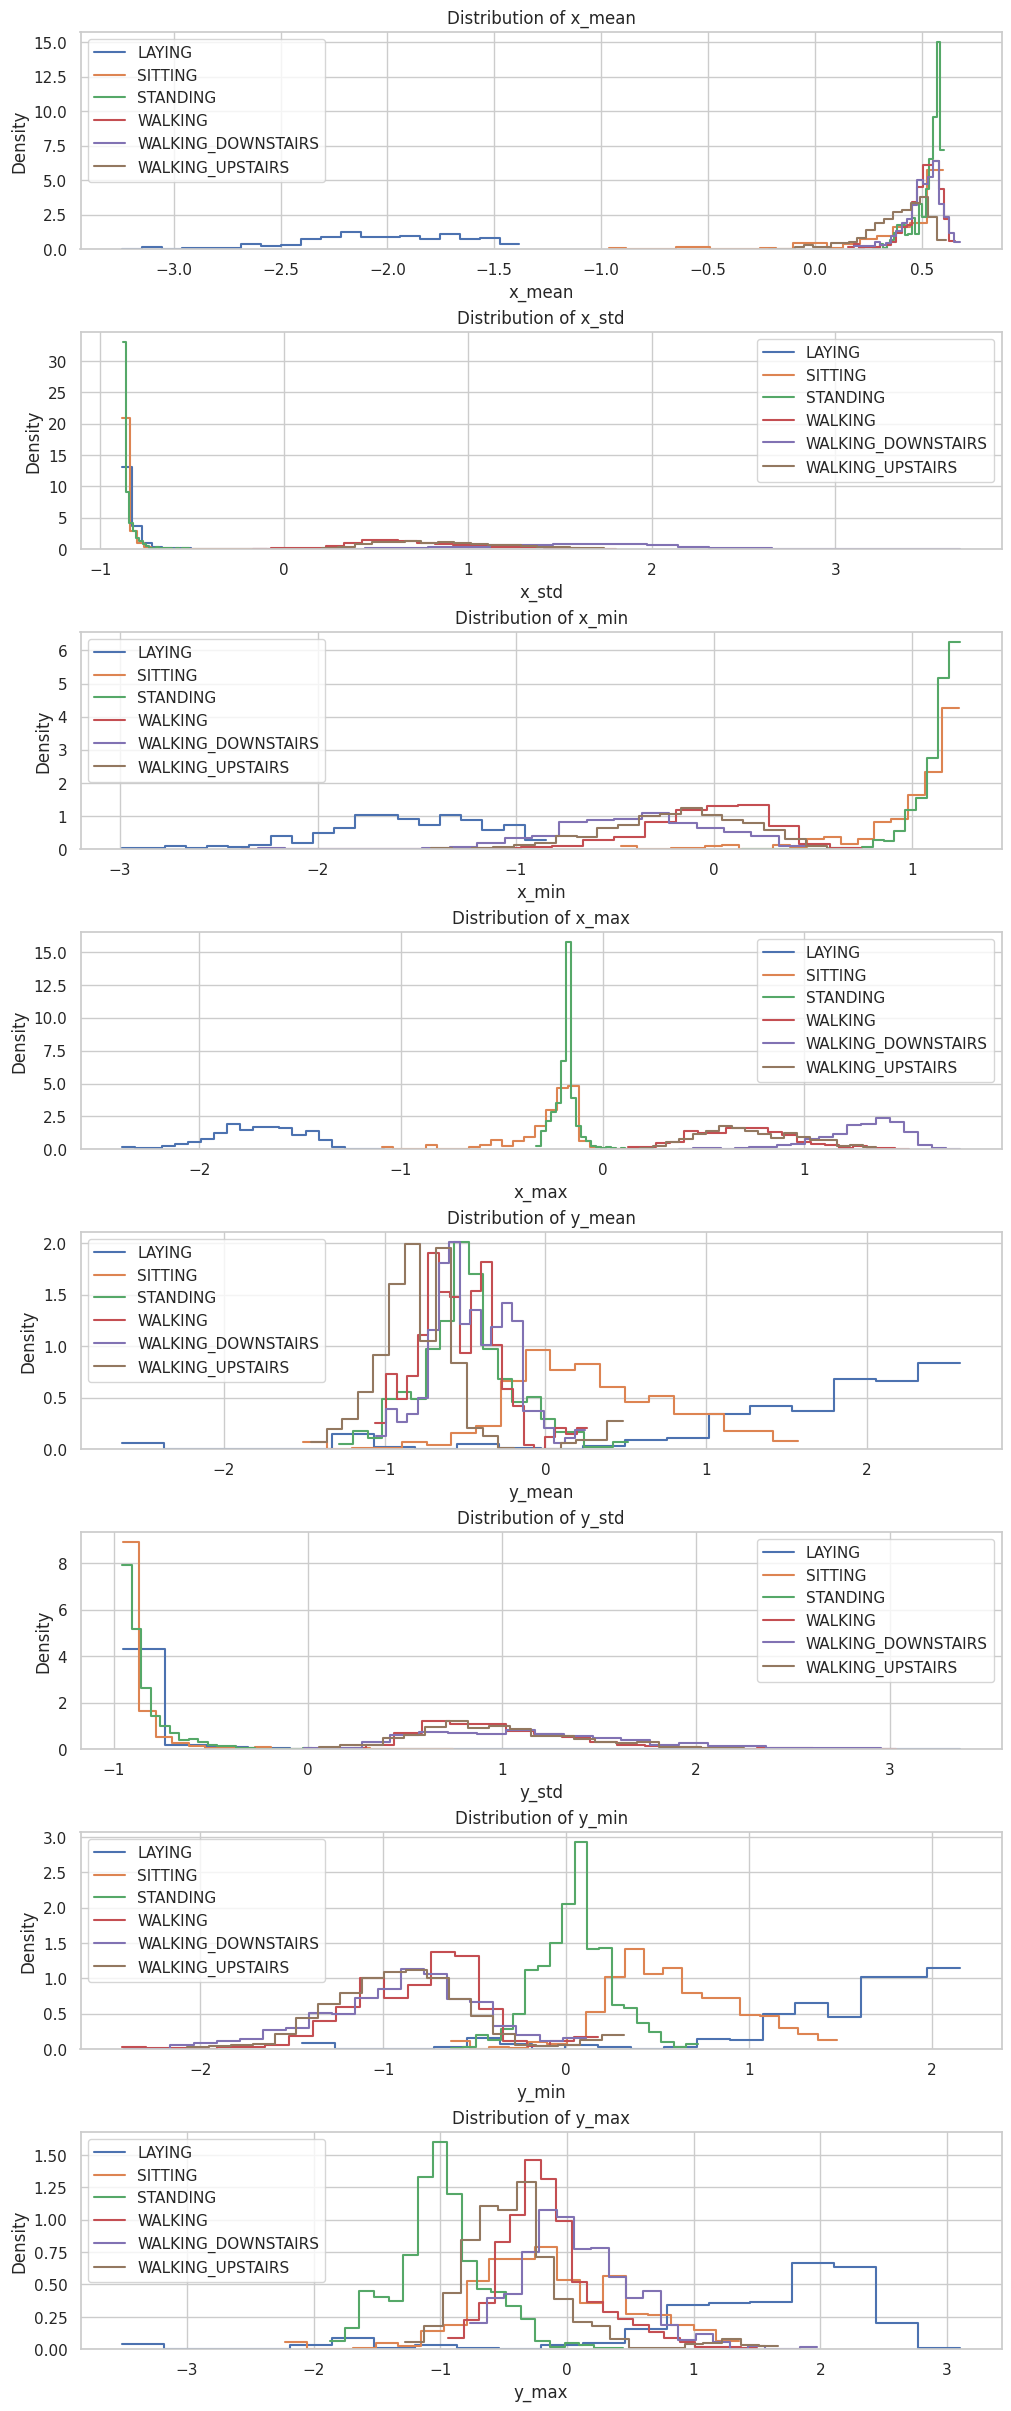

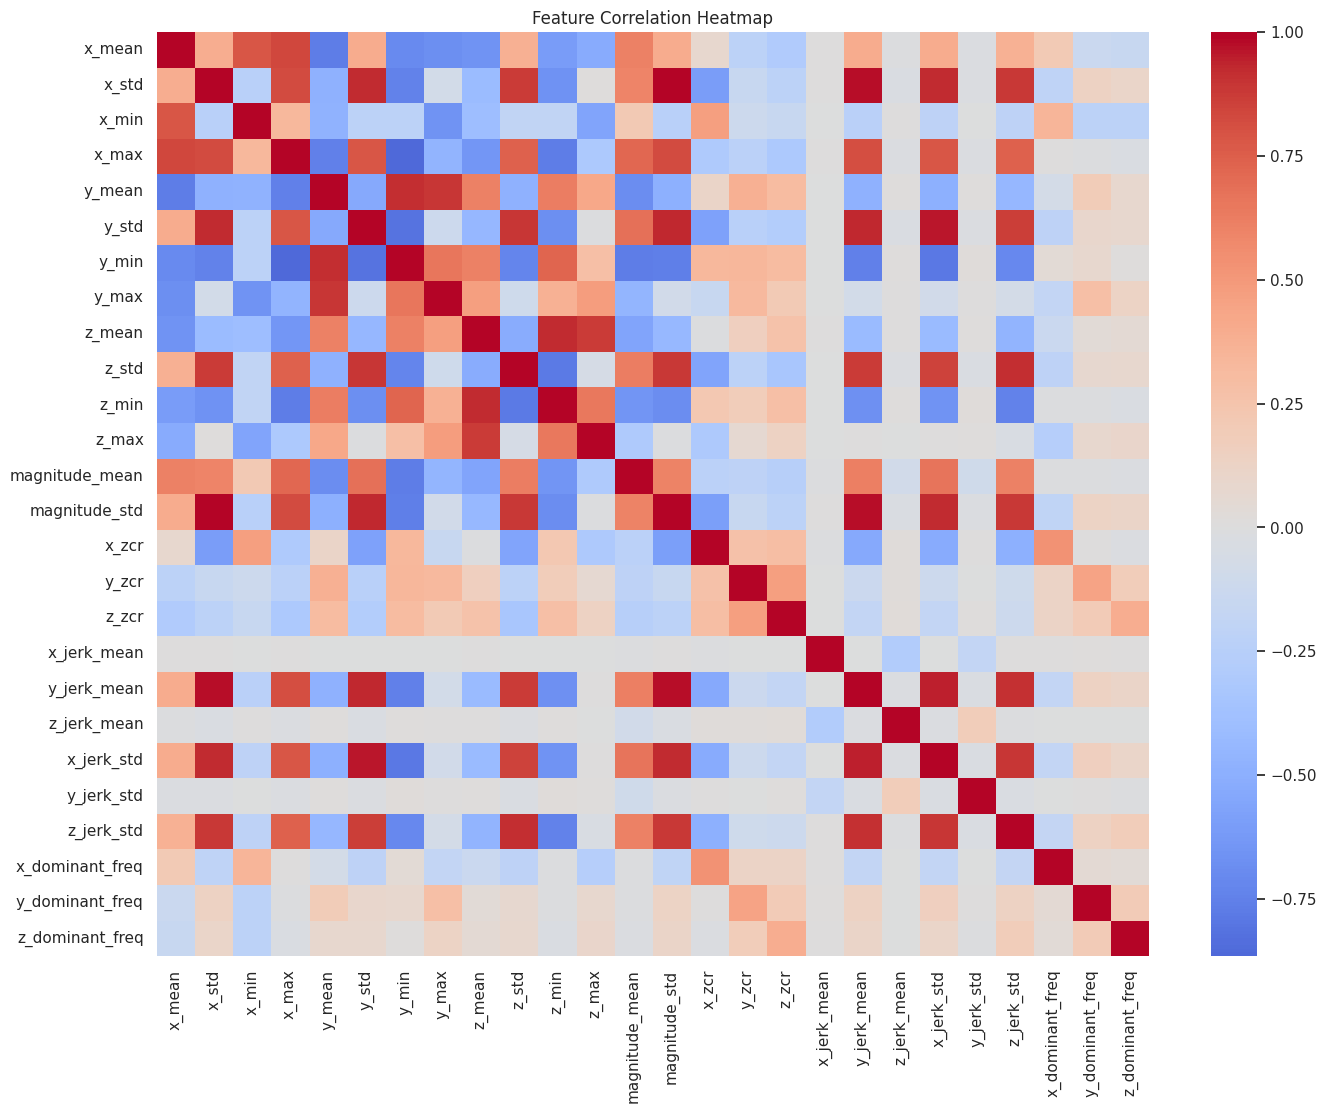

,feature_a,feature_b,correlation,abs_correlation
36,x_std,magnitude_std,0.996910,0.996910
41,x_std,y_jerk_mean,0.973593,0.973593
251,magnitude_std,y_jerk_mean,0.971720,0.971720
129,y_std,x_jerk_std,0.961872,0.961872
298,y_jerk_mean,x_jerk_std,0.948778,0.948778
122,y_std,magnitude_std,0.929504,0.929504
127,y_std,y_jerk_mean,0.928071,0.928071
28,x_std,y_std,0.924848,0.924848
253,magnitude_std,x_jerk_std,0.923649,0.923649
173,z_mean,z_min,0.923492,0.923492


In [32]:
plot_feature_histograms(processed_bundle.X_train, processed_bundle.y_train, max_features=8)
corr = plot_correlation_heatmap(processed_bundle.X_train)
display(top_correlated_pairs(corr, threshold=0.85).head(20))

## Q1.3

Από τα ιστογράμματα φαίνεται ότι τα πιο χρήσιμα features είναι αυτά που δείχνουν πόσο έντονη είναι η κίνηση, όπως τα std, το magnitude_std και τα jerk features. Στις δυναμικές δραστηριότητες, δηλαδή στο περπάτημα και στις σκάλες, οι τιμές αυτές είναι γενικά μεγαλύτερες. Στις στάσιμες δραστηριότητες, όπως SITTING, STANDING και LAYING, είναι πιο μικρές, γιατί το σήμα αλλάζει λιγότερο.
Η μεγαλύτερη επικάλυψη φαίνεται ανάμεσα σε SITTING και STANDING. Αυτό είναι λογικό, γιατί και οι δύο δραστηριότητες είναι στάσιμες και διαφέρουν κυρίως στον προσανατολισμό του σώματος ή του κινητού. Η LAYING ξεχωρίζει πιο εύκολα, επειδή ο προσανατολισμός της βαρύτητας στους άξονες είναι πιο διαφορετικός. Οι walking κλάσεις ξεχωρίζουν από τις στάσιμες, αλλά μπορεί να μοιάζουν μεταξύ τους επειδή όλες έχουν παρόμοιο μοτίβο κίνησης.
Ο πίνακας δείχνει ότι αρκετά features λένε σχεδόν την ίδια πληροφορία. Πχ, x_std και magnitude_std έχουν correlation 0.997, x_std και y_jerk_mean 0.974, και y_std με x_jerk_std 0.962. Άρα πολλά features μετρούν παρόμοια πράγματα, όπως ένταση, διασπορά και απότομες αλλαγές επιτάχυνσης. Αυτό μπορεί να επηρεάσει περισσότερο μοντέλα όπως k-NN, Logistic Regression και SVM, ενώ τα Decision Trees συνήθως επηρεάζονται λιγότερο.


## 1.4 Μείωση διαστάσεων και οπτικοποίηση

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


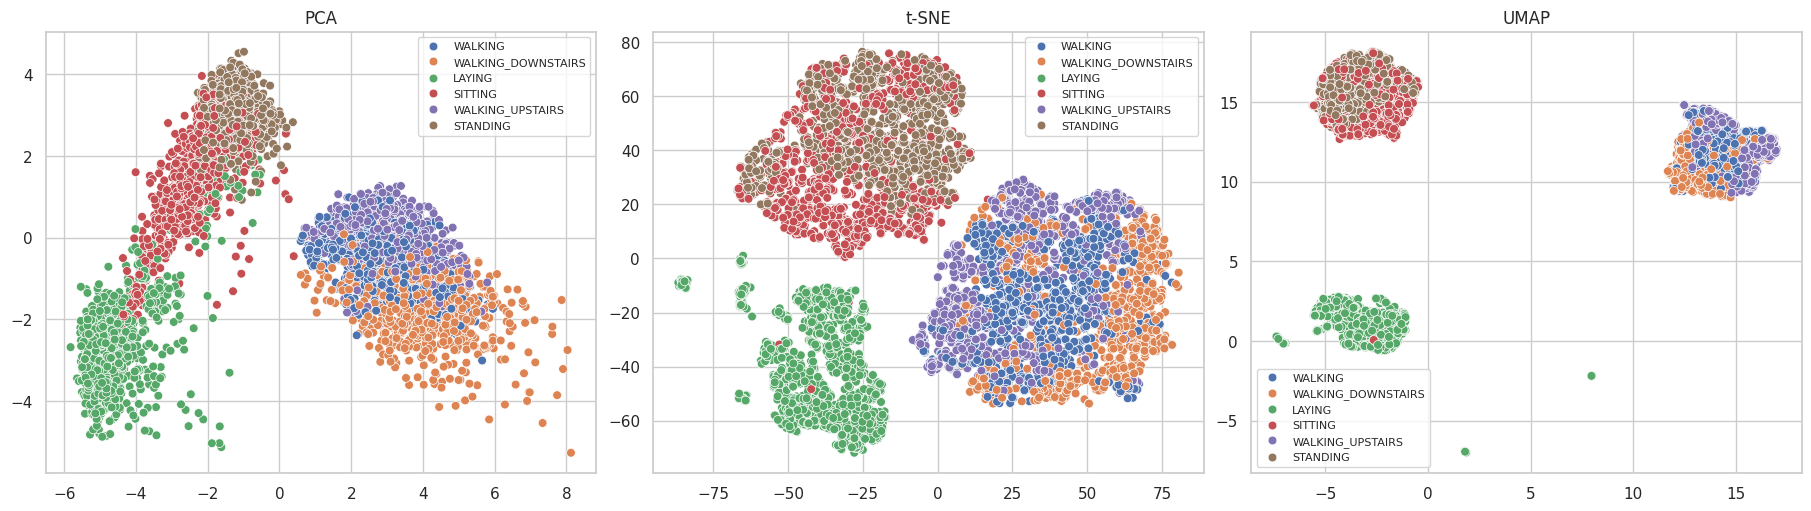

PCA explained variance ratio: [0.41623053 0.17168516]


In [33]:
embedding_outputs = plot_embeddings(processed_bundle.X_train, processed_bundle.y_train)
print('PCA explained variance ratio:', embedding_outputs.get('PCA_explained_variance_ratio'))

## Q1.4

Στο PCA οι δύο πρώτες συνιστώσες εξηγούν περίπου 58.8% της συνολικής διακύμανσης. Αυτό σημαίνει ότι στις 2 διαστάσεις βλέπουμε αρκετή πληροφορία, αλλά όχι όλη. Άρα αν κάποιες κλάσεις φαίνονται μπερδεμένες στο PCA plot, δεν σημαίνει ότι είναι αδύνατο να διαχωριστούν. Απλώς χρειάζονται περισσότερες διαστάσεις.
Η εικόνα συμφωνεί. Η LAYING φαίνεται να ξεχωρίζει καλύτερα, ενώ οι SITTING και STANDING είναι πιο κοντά μεταξύ τους. Οι walking δραστηριότητες ξεχωρίζουν πιο εύκολα από τις στάσιμες, αλλά μεταξύ τους έχουν κάποια επικάλυψη γιατί έχουν παρόμοια κίνηση.
Το PCA είναι γραμμική μέθοδος, ενώ το t-SNE/UMAP δείχνει καλύτερα τοπικές ομάδες και μη γραμμικές σχέσεις. Τα plots βοηθούν στην κατανόηση των δεδομένων, αλλά δεν αρκούν μόνα τους για να κρίνουμε το τελικό μοντέλο. Το ότι καλύτερο μοντέλο βγήκε το SVM με rbf kernel δείχνει ότι ο διαχωρισμός των δραστηριοτήτων δεν είναι τελείως γραμμικός.


## 2. Εκπαίδευση και Σύγκριση Αλγορίθμων

In [34]:
results_df, fitted_models = run_model_selection(
    processed_bundle.X_train,
    processed_bundle.y_train,
    processed_bundle.X_val,
    processed_bundle.y_val,
    processed_bundle.X_test,
    processed_bundle.y_test,
)
display(results_df)

,Algorithm,Best Params,Val Acc (%),Test Acc (%),F1 macro (%)
4,SVM,"{'C': 10, 'kernel': 'rbf'}",94.174757,94.045307,94.204598
5,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 1}",92.103560,92.621359,92.331865
3,Logistic Regression,"{'C': 100, 'penalty': 'l1', 'solver': 'libline...",91.521036,92.103560,92.124780
1,k-NN,"{'metric': 'euclidean', 'n_neighbors': 11}",90.161812,89.061489,88.833307
2,Naive Bayes,{},85.954693,83.948220,83.118385
0,Naive Baseline,{},18.834951,18.899676,5.298494


Best model: SVM
Test accuracy: 94.05
Test macro F1: 94.2


,class,precision,recall,f1,support
0,LAYING,1.000000,1.000000,1.000000,292
1,SITTING,0.885827,0.845865,0.865385,266
2,STANDING,0.865320,0.898601,0.881647,286
3,WALKING,0.954373,0.969112,0.961686,259
4,WALKING_DOWNSTAIRS,0.967442,0.985782,0.976526,211
5,WALKING_UPSTAIRS,0.982143,0.952381,0.967033,231


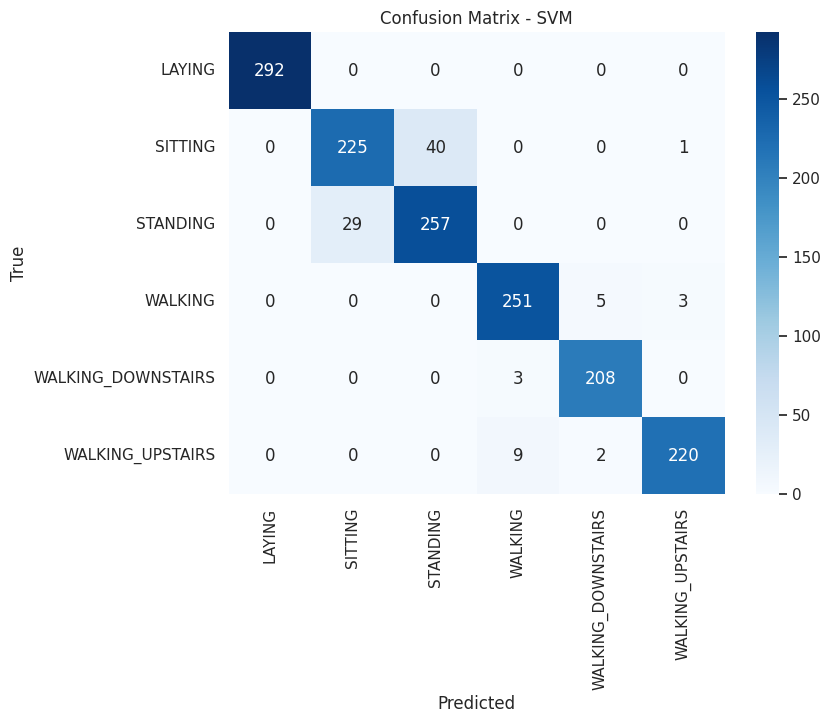

In [35]:
best_non_baseline = results_df[results_df['Algorithm'] != 'Naive Baseline'].iloc[0]
best_model_name = best_non_baseline['Algorithm']
best_model = fitted_models[best_model_name]
best_test_metrics = evaluate_model(best_model, processed_bundle.X_test, processed_bundle.y_test)
print('Best model:', best_model_name)
print('Test accuracy:', round(best_test_metrics['accuracy'] * 100, 2))
print('Test macro F1:', round(best_test_metrics['f1_macro'] * 100, 2))
display(best_test_metrics['per_class'])
cm_test = plot_confusion(processed_bundle.y_test, best_test_metrics['predictions'], f'Confusion Matrix - {best_model_name}')

## Q2.1

Ο καλύτερος αλγόριθμος ήταν το SVM με C=10 και rbf kernel. Πέτυχε 94.17% στο validation, 94.05% στο test και 94.20% macro-F1. Η επίδοση στο validation και στο test είναι πολύ κοντά, άρα το μοντέλο φαίνεται να γενικεύει καλά και να μην έχει έντονο overfitting.
Τα υπόλοιπα μοντέλα είχαν επίσης καλή επίδοση, αλλά λίγο χαμηλότερη. Το Decision Tree έφτασε 92.62% test accuracy, η Logistic Regression 92.10%, το k-NN 89.06% και το Naive Bayes 83.95%. Το Naive Baseline ήταν πολύ χαμηλά, με 18.90% accuracy και 5.30% macro-F1, άρα τα κανονικά μοντέλα μαθαίνουν πραγματικά χρήσιμη πληροφορία από τα features.

In [36]:
universal_mistakes = universal_errors(fitted_models, processed_bundle.X_test, processed_bundle.y_test)
display(universal_mistakes.head(10))
print('Samples misclassified by all non-baseline models:', len(universal_mistakes))

,x_mean,x_std,x_min,x_max,y_mean,y_std,y_min,y_max,z_mean,z_std,...,x_jerk_mean,y_jerk_mean,z_jerk_mean,x_jerk_std,y_jerk_std,z_jerk_std,x_dominant_freq,y_dominant_freq,z_dominant_freq,true_label
8139,0.594066,-0.860039,1.217697,-0.139944,-0.232581,-0.865509,0.234749,-0.675022,-0.083619,-0.842118,...,-0.010263,-0.853956,0.074606,-0.859269,0.063067,-0.799891,0.766974,0.092896,-0.738989,SITTING
8410,0.568187,-0.860123,1.183721,-0.164338,0.199177,-0.809303,0.523825,-0.161778,-0.022614,-0.788555,...,0.020802,-0.841346,0.076278,-0.783640,0.146454,-0.784332,3.242060,-0.694046,-0.738989,STANDING
7387,0.562650,-0.874021,1.199976,-0.180225,-0.305401,-0.904738,0.190469,-0.819128,0.229349,-0.898026,...,-0.003900,-0.866661,0.101124,-0.849667,0.080692,-0.826606,0.091951,-0.431732,-0.175097,SITTING
7397,0.591998,-0.855618,1.200564,-0.141464,-0.371356,-0.883798,0.149798,-0.879199,-0.120562,-0.860272,...,-0.025234,-0.825959,-0.030020,-0.865643,0.070938,-0.811327,3.242060,-0.956360,-0.738989,SITTING
6324,0.553658,-0.861570,1.181482,-0.175201,-0.622367,-0.883924,-0.032267,-1.161284,-0.485531,-0.870056,...,0.031324,-0.844770,0.140098,-0.832957,-0.001937,-0.797210,-1.033088,-0.956360,1.234633,SITTING
3092,0.460603,-0.873006,1.080440,-0.244091,-0.438521,-0.906779,0.117258,-0.952135,0.641044,-0.888712,...,-0.003755,-0.866954,-0.107495,-0.880224,0.070561,-0.826349,3.692076,-0.956360,-0.738989,SITTING
8444,0.585367,-0.851026,1.170069,-0.146617,-0.430616,-0.755617,0.028161,-0.798047,-0.144832,-0.699649,...,0.107444,-0.833965,0.335532,-0.711261,0.131464,-0.728790,0.766974,-0.956360,-0.738989,SITTING
8138,0.594763,-0.833516,1.174713,-0.139944,-0.254697,-0.758225,0.157553,-0.734536,-0.067041,-0.724475,...,-0.006312,-0.817824,0.231755,-0.816487,-0.279034,-0.713783,0.991982,-0.169418,-0.738989,SITTING
2311,0.305514,0.209893,0.309681,0.274845,-0.681999,0.661324,-0.612563,-0.263548,-1.465491,1.357548,...,-0.168329,0.139954,-0.114369,0.217544,-2.139710,0.639747,-0.358065,-0.694046,0.106849,WALKING
9628,0.535881,-0.809827,1.074223,-0.146277,-0.097597,-0.672391,0.262592,-0.348540,0.406396,-0.616325,...,0.058074,-0.761224,-0.010160,-0.756016,-0.107240,-0.727520,1.667006,-0.956360,-0.738989,SITTING


Samples misclassified by all non-baseline models: 14


## Q2.2

Στο confusion matrix του SVM φαίνεται ότι η LAYING ταξινομείται τέλεια, με precision, recall και F1 ίσα με 1. Αυτό δείχνει ότι τα features αρκούν για να ξεχωρίσουν την κατάκλιση από τις άλλες δραστηριότητες. Πολύ καλή επίδοση έχουν και οι walking κλάσεις, με F1 περίπου 0.96-0.98.
Τα περισσότερα λάθη εμφανίζονται ανάμεσα σε SITTING και STANDING. Η SITTING έχει F1 0.865 και η STANDING 0.882. Αυτό είναι αναμενόμενο, γιατί και οι δύο είναι στάσιμες δραστηριότητες και έχουν μικρή μεταβλητότητα στο σήμα. Η διαφορά τους βασίζεται περισσότερο στον προσανατολισμό του κινητού παρά στην ένταση της κίνησης.
Άρα το μοντέλο δουλεύει καλά συνολικά, αλλά δυσκολεύεται εκεί όπου οι ίδιες οι δραστηριότητες έχουν παρόμοια χαρακτηριστικά.


## Q2.3

Υπάρχουν 14 δείγματα που ταξινομήθηκαν λάθος από όλους τους μη-baseline αλγορίθμους. Αυτό δείχνει ότι το πρόβλημα δεν είναι μόνο ένας συγκεκριμένος αλγόριθμος. Μάλλον αυτά τα δείγματα είναι πραγματικά δύσκολα ή βρίσκονται σε περιοχή όπου οι κλάσεις επικαλύπτονται.
Στα πρώτα universal mistakes υπάρχουν πολλά SITTING και STANDING δείγματα, κάτι που συμφωνεί με το confusion matrix. Αυτές οι δύο κλάσεις έχουν χαμηλή κίνηση και μοιάζουν πολύ στα std και jerk features. Έτσι, μικρές διαφορές στη θέση του κινητού μπορούν να αλλάξουν την πρόβλεψη.
Υπάρχει και τουλάχιστον ένα WALKING δείγμα στα πρώτα λάθη. Αυτό μπορεί να είναι κάποιο πιο αργό ή ασυνήθιστο περπάτημα.


## Q2.4
Αν δύο μοντέλα έχουν κοντινή επίδοση, μπορεί να προτιμηθεί το πιο απλό. Σε αυτό το πρόβλημα όμως το SVM είναι καλή επιλογή, γιατί έχει την καλύτερη επίδοση σε validation και test και το καλύτερο macro-F1. Αν ο στόχος ήταν κυρίως η ερμηνεία ή η χρήση σε πολύ περιορισμένη συσκευή, τότε θα μπορούσε να προτιμηθεί ένα πιο απλό μοντέλο με χαμηλότερη επίδοση.


## 3.0 Εξαγωγή χαρακτηριστικών από τα ίδια δεδομένα

In [37]:
X_own_raw, y_own, own_debug = load_own_har_features(
    OWN_METADATA_CSV,
    OWN_DATA_DIR,
    sample_rate_hz=OWN_SAMPLE_RATE_HZ,
)
X_own = transform_own_features(X_own_raw, imputer, scaler)
display(own_debug.head())
display(y_own.value_counts().sort_index())
print('Διαστάσεις:', X_own.shape)


,filename,activity,original_length,used_length
0,1.csv,STANDING,1316,128
1,2.csv,STANDING,1339,128
2,3.csv,STANDING,1190,128
3,4.csv,STANDING,1083,128
4,5.csv,STANDING,1285,128


,count
activity,
LAYING,4
SITTING,7
STANDING,8
WALKING,6


Διαστάσεις: (25, 26)


## Q3.0

Στα own data φόρτωσα 25 CSV αρχεία με 4 κλάσεις: 8 STANDING, 7 SITTING, 6 WALKING και 4 LAYING. Τα αρχεία είχαν διαφορετικό μήκος, περίπου από 916 έως 1607 δείγματα, οπότε έγινε resampling σε μήκος 128.
Μετά το resampling έβγαλα τα ίδια 26 features και χρησιμοποίησα τον ίδιο imputer και scaler που είχαν γίνει fit στα UCI/Kaggle training data. Αυτό είναι σωστό, γιατί θέλουμε να δούμε αν το μοντέλο που εκπαιδεύτηκε στο αρχικό dataset μπορεί να δουλέψει και στα δικά μου δεδομένα. Τα δεδομένα φορτώθηκαν σωστά, αλλά τα αποτελέσματα δείχνουν ότι η κατανομή τους είναι πολύ διαφορετική.


,feature,mean_kaggle,mean_own,std_kaggle,normalized_shift
22,z_jerk_std,1.478449e-18,19.756436,1.000069,19.755066
20,x_jerk_std,-3.449715e-18,14.515558,1.000069,14.514551
18,y_jerk_mean,-4.287503e-17,10.451306,1.000069,10.450581
12,magnitude_mean,-1.220213e-15,-8.289211,1.000069,8.288636
9,z_std,5.519544e-17,7.557052,1.000069,7.556528
5,y_std,-7.687936e-17,7.164533,1.000069,7.164036
2,x_min,-5.913797e-18,-6.933980,1.000069,6.933499
24,y_dominant_freq,-4.829601e-17,6.126117,1.000069,6.125692
7,y_max,-1.182759e-17,6.059920,1.000069,6.059500
25,z_dominant_freq,2.562645e-17,5.982602,1.000069,5.982187


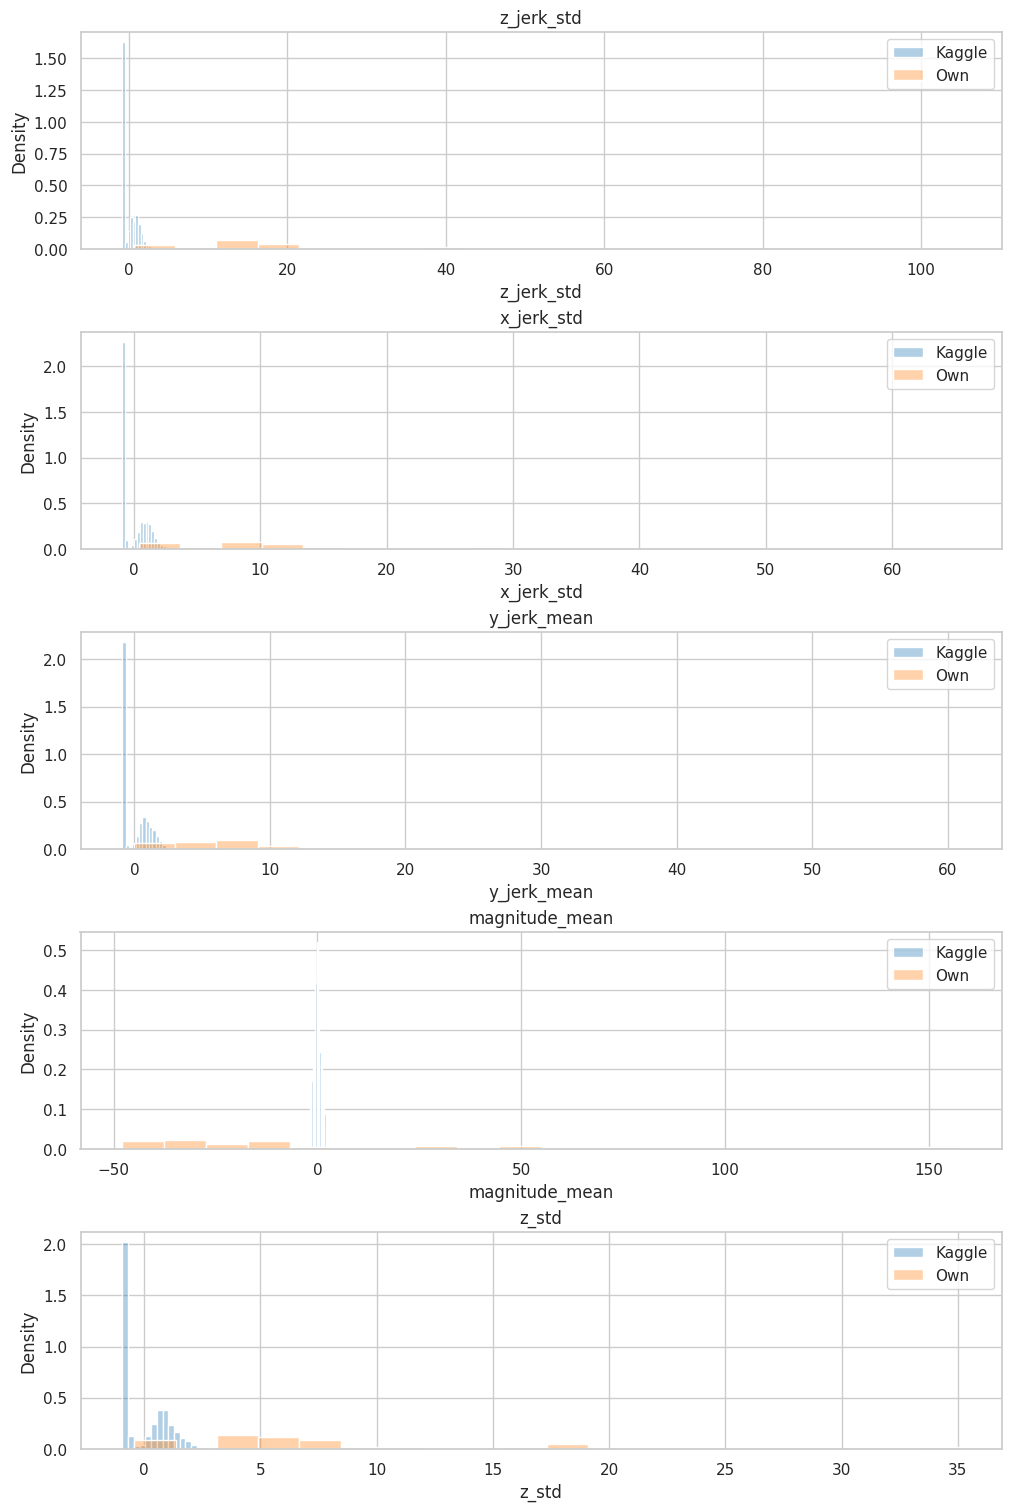

In [38]:
shift_table = distribution_shift_table(processed_bundle.X_train, X_own)
display(shift_table.head(10))
plot_shifted_features(processed_bundle.X_train, X_own, shift_table['feature'].head(5).tolist())

In [39]:
retrain_results = retrain_with_own_data(
    best_model,
    processed_bundle.X_train,
    processed_bundle.y_train,
    processed_bundle.X_test,
    processed_bundle.y_test,
    X_own,
    y_own,
)
display(retrain_results)

feature_to_drop = shift_table.iloc[0]['feature']
drop_feature_results = remove_feature_and_retrain(
    best_model,
    feature_to_drop,
    processed_bundle,
    X_own,
    y_own,
)
print('Dropped feature:', feature_to_drop)
display(drop_feature_results)

,scenario,accuracy,f1_macro
0,Mix Kaggle + own-train -> own-test,0.153846,0.066667
1,Mix Kaggle + own-train -> Kaggle test,0.941748,0.943440
2,Own-train only -> own-test,1.000000,1.000000
3,Own-train only -> Kaggle test,0.146926,0.048712


Dropped feature: z_jerk_std


,scenario,accuracy,f1_macro
0,Kaggle test,0.940453,0.941982
1,Own data,0.160000,0.068966


## Q3.1

Το καλύτερο μοντέλο στο Kaggle/UCI test set ήταν το SVM, με 94.05% accuracy και 94.20% macro-F1. Στα own data όμως η επίδοση είναι πολύ χαμηλή. Το σενάριο Mix Kaggle + own-train -> own-test έδωσε μόνο 15.38% accuracy και 6.67% macro-F1, ενώ μετά την αφαίρεση του z_jerk_std η επίδοση στα own data ήταν 16.00% accuracy και 6.90% macro-F1.
Άρα η διαφορά είναι τεράστια: περίπου 94% στο αρχικό test set, αλλά μόνο 15-16% στα δικά μου δεδομένα. Αυτό δείχνει ότι το SVM δεν είναι κακό μοντέλο γενικά. Το πρόβλημα είναι ότι τα own data έχουν διαφορετική κατανομή από τα δεδομένα εκπαίδευσης.
Επίσης, το own dataset είναι μικρό και έχει μόνο 4 κλάσεις, άρα η αξιολόγηση δεν είναι τόσο σταθερή όσο στο UCI HAR.


## Q3.2

Τα UCI HAR δεδομένα έχουν μαζευτεί με συγκεκριμένο πρωτόκολλο, ενώ τα δικά μου δεδομένα προέρχονται από άλλη συσκευή, άλλο χρήστη και πιθανώς άλλη θέση κινητού. Έτσι αλλάζουν η κλίμακα, ο θόρυβος, ο προσανατολισμός των αξόνων και ο τρόπος που φαίνονται οι ίδιες κινήσεις.
Πριν χρησιμοποιηθεί το μοντέλο σε νέο περιβάλλον, θα έπρεπε να ελεγχθούν μερικά πράγματα: αν οι στήλες x/y/z είναι σωστές, αν η συχνότητα δειγματοληψίας είναι συμβατή, αν το scaling εφαρμόζεται σωστά και αν τα features έχουν παρόμοια κατανομή με το training set. Επίσης θα χρειαζόταν ένα μικρό labeled pilot set από το νέο περιβάλλον, ώστε να μετρηθεί η νέα πραγματική επίδοση


## Q3.3

Τα features με τη μεγαλύτερη απόκλιση ήταν τα z_jerk_std (19.76), x_jerk_std (14.51), y_jerk_mean (10.45), magnitude_mean (8.29) και z_std (7.56). Επειδή τα features είναι scaled με βάση το UCI/Kaggle training set, τόσο μεγάλες τιμές σημαίνουν ότι τα own data είναι πολύ μακριά από την αρχική κατανομή.
Τα περισσότερα από αυτά τα features σχετίζονται με jerk, ένταση και μεταβλητότητα της κίνησης. Δηλαδή δεν αλλάζει απλώς μια μέση τιμή, αλλά ο ίδιος ο τρόπος που κινείται ή καταγράφεται το σήμα. Αυτό μπορεί να οφείλεται σε διαφορετική θέση κινητού, διαφορετική συσκευή, διαφορετικό προσανατολισμό αξόνων.
Επειδή αυτά τα features ήταν σημαντικά για τον διαχωρισμό των δραστηριοτήτων στο αρχικό dataset, η μεγάλη μετατόπισή τους εξηγεί γιατί το μοντέλο δυσκολεύεται τόσο πολύ στα own data.


## Q3.4

Τα πιο shifted features είναι ακριβώς αυτά που βοηθούν πολύ στον διαχωρισμό των δραστηριοτήτων: std, magnitude και jerk. Αυτά δείχνουν αν η κίνηση είναι έντονη ή στάσιμη. Αν όμως οι τιμές τους στα own data είναι σε τελείως άλλη κλίμακα, τότε το μοντέλο βλέπει τα δικά μου δείγματα σε διαφορετικές περιοχές του feature space.
Γι' αυτό τα λάθη στα own data δεν φαίνεται να οφείλονται σε ένα μόνο feature ή σε μια μόνο σύγχυση κλάσεων. Πολλά σχετικά features έχουν μετακινηθεί μαζί, άρα αλλάζει συνολικά η γεωμετρία των δεδομένων. Αυτό εξηγεί γιατί η αφαίρεση μόνο του z_jerk_std δεν αρκει.


## Q3.5

Τα αποτελέσματα των παρεμβάσεων δείχνουν ότι το βασικό πρόβλημα είναι το distribution shift. Το Mix Kaggle+own-train-> own-test έδωσε μόνο 15.38% accuracy και 6.67% macro-F1. Από την άλλη, το αντίστοιχο για Kaggle έμεινε πολύ υψηλό, με 94.17% accuracy και 94.34% macro-F1. Άρα τα λίγα own samples δεν χαλάνε το Kaggle domain, αλλά δεν αρκούν για να μάθει καλά.
Το Own-train only -> own-test έδωσε 100%, αλλά αυτό δεν είναι αξιόπιστη ένδειξη, γιατί το own dataset έχει μόνο 25 δείγματα. Είναι πολύ πιθανό να έχουμε overfitting. Αυτό φαίνεται και από το Own-train only-> Kaggle test, όπου η επίδοση πέφτει σε 14.69% accuracy και 4.87% macro-F1.
Η αφαίρεση του z_jerk_std επίσης δεν έλυσε το πρόβλημα. Στο Kaggle test η επίδοση έμεινε ίδια, ενώ στα own data ανέβηκε λίγο, σε 16.00% accuracy και 6.90% macro-F1. Άρα το πρόβλημα είναι η συνολική διαφορά ανάμεσα στα δύο datasets.


## Q3.6

Καμία παρέμβαση δεν βελτίωσε ουσιαστικά την επίδοση στα own. Το mixed training κράτησε πολύ καλή επίδοση στο Kaggle test, αλλά δεν βοήθησε αρκετά στο own. Η αφαίρεση του z_jerk_std ήταν επίσης σχεδόν μηδενιική: δεν χάλασε το Kaggle, αλλά στα own έδωσε πολύ μικρή βελτίωση.
Το own-only training φαίνεται καλό μόνο επειδή δίνει 100% στο own-test, αλλά αυτό είναι μάλλον overfitting λόγω του πολύ μικρού όγκου. Το ίδιο αποτυγχάνει τελείως στο Kaggle test, άρα δεν έχει γενικούς κανόνες για τις δραστηριότητες.
Η καλύτερη επόμενη κίνηση θα ήταν να μαζευτούν περισσότερα own data, να ελεγχθούν καλύτερα οι άξονες, η συχνότητα και το scaling, και μετά να γίνει αξιολόγηση.


## Q3.7

Αν ξανασχεδίαζα τη συλλογή, θα κρατούσα το κινητό πάντα στην ίδια θέση, με ίδιο προσανατολισμό, ίδια διάρκεια και όσο γίνεται ίδια συχνότητα. Έτσι τα σήματα θα ήταν πιο συγκρίσιμα μεταξύ τους και πιο κοντά στο training domain.
Θα μάζευα επίσης περισσότερα δείγματα και για τις 6 κλάσεις, όχι μόνο για τις 4 που υπάρχουν τώρα. Ιδανικά θα έβαζα και άλλους χρήστες ή συσκευές, ώστε το μοντέλο να μη μάθει μόνο τον δικό μου τρόπο κίνησης. Για τις στάσιμες δραστηριότητες θα πρόσεχα τη θέση του κινητού, γιατί εκεί ο διαχωρισμός βασίζεται πολύ στον προσανατολισμό.
Το πείραμα δείχνει ότι δεν αρκεί τα CSV να έχουν σωστό format, αλλά πρέπει και τα δεδομένα να μοιάζουν στατιστικά με αυτά που είδε το μοντέλο στην εκπαίδευση.
